In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("customer_churn.csv")

print(df.head())
print(df.info())
print(df.describe())

  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID  

In [22]:
print(df.isnull().sum())

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


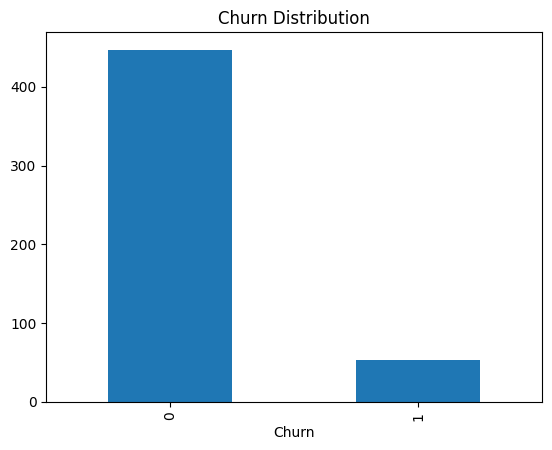

CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object


In [23]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()
print(df.dtypes)

In [24]:
categorical_cols = df.select_dtypes(include="object").columns
print(categorical_cols)

Index(['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling'], dtype='object')


In [25]:
le = LabelEncoder()

df["Contract_encoded"] = le.fit_transform(df["Contract"])
df["Payment_encoded"] = le.fit_transform(df["PaymentMethod"])
df = pd.get_dummies(df, columns=["Contract","PaymentMethod"], drop_first=True)
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes":1,"No":0})

In [26]:
num_cols = ["Tenure","MonthlyCharges","TotalCharges"]
scaler = StandardScaler()

df_standard = df.copy()
df_standard[num_cols] = scaler.fit_transform(df_standard[num_cols])

In [27]:
minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[num_cols] = minmax.fit_transform(df_minmax[num_cols])

In [28]:
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["MonthlyCharges"] < lower) | (df["MonthlyCharges"] > upper)]

print(len(outliers))

0


In [29]:
z = np.abs(stats.zscore(df[num_cols]))

outliers = df[(z > 3).any(axis=1)]

print(outliers.shape)

(0, 13)


In [30]:
df["MonthlyCharges"] = np.where(
    df["MonthlyCharges"] > upper,
    upper,
    df["MonthlyCharges"]
)

In [31]:
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["Tenure"] + 1)
df["CLV"] = df["MonthlyCharges"] * df["Tenure"]
df["PaymentEfficiency"] = df["TotalCharges"] / (df["MonthlyCharges"] + 1)
df["LongTermCustomer"] = (df["Tenure"] > 24).astype(int)
df["LongTermCustomer"] = (df["Tenure"] > 24).astype(int)
df["HighSpender"] = (df["MonthlyCharges"] > df["MonthlyCharges"].mean()).astype(int)
df["ChargesPerTenure"] = df["TotalCharges"] / (df["Tenure"] + 1)

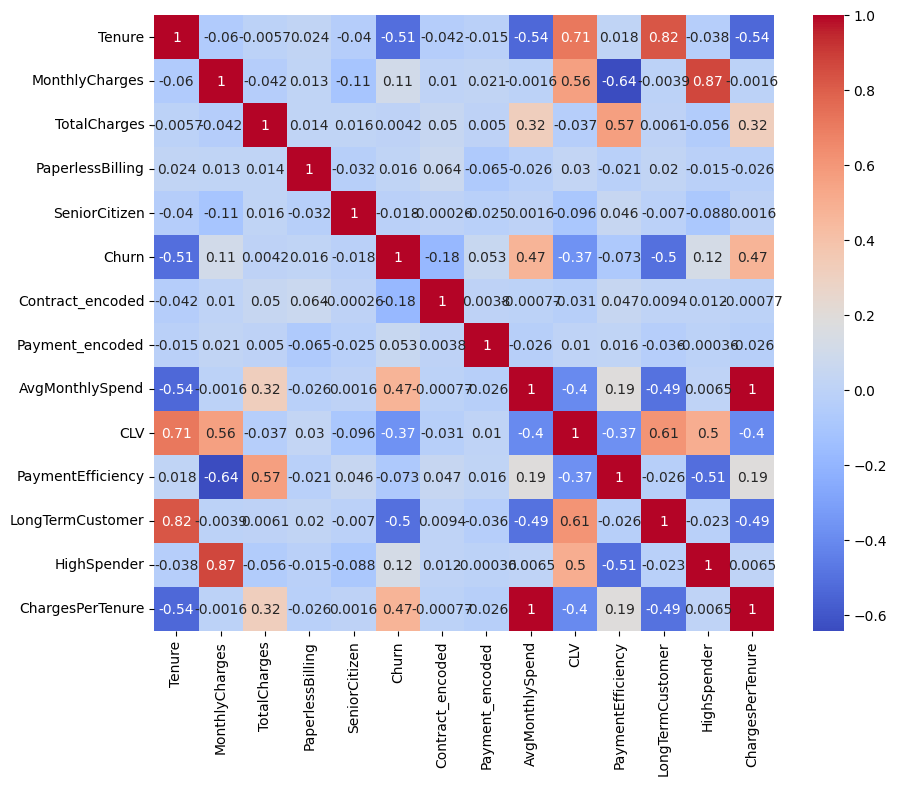

In [32]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.show()

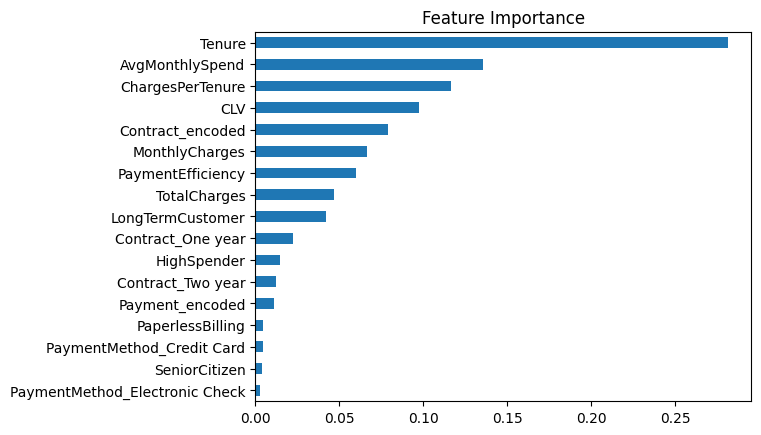

In [33]:

X = df.drop(["Churn","CustomerID"], axis=1)
y = df["Churn"]

model = RandomForestClassifier()

model.fit(X,y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [34]:

numeric_features = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "CLV",
    "PaymentEfficiency",
    "ChargesPerTenure"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="passthrough"
)

In [35]:
print(df.columns)

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges',
       'PaperlessBilling', 'SeniorCitizen', 'Churn', 'Contract_encoded',
       'Payment_encoded', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check',
       'AvgMonthlySpend', 'CLV', 'PaymentEfficiency', 'LongTermCustomer',
       'HighSpender', 'ChargesPerTenure'],
      dtype='object')


In [36]:


X = df.drop(["Churn","CustomerID"], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [37]:
pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))

Accuracy: 0.95
